In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX


C:\Users\Hp\AppData\Local\Temp\ipykernel_12132\781280679.py:31: RuntimeWarning: invalid value encountered in sqrt
  portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))


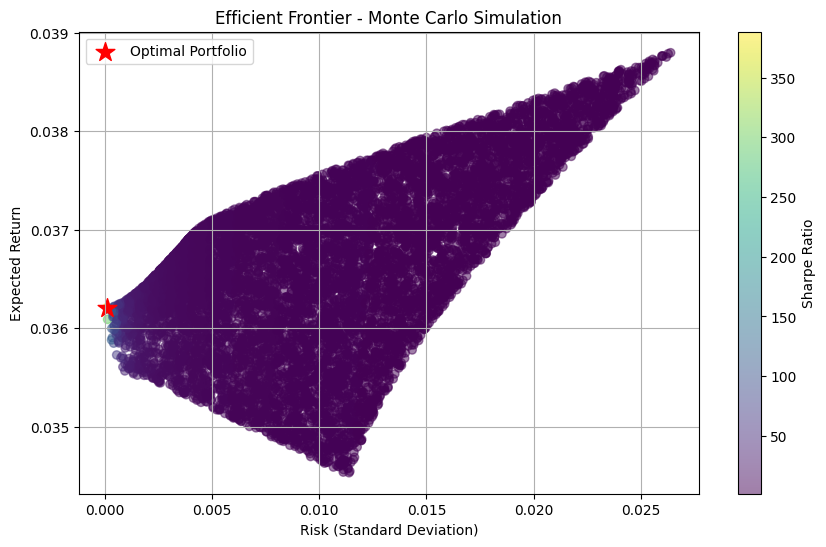

Optimal Portfolio:
Return            0.036209
Risk              0.000093
Sharpe Ratio    388.467038
TSLA Weight       0.078539
BND Weight        0.685777
SPY Weight        0.235683
Name: 2199, dtype: float64


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Number of random portfolios to generate
num_portfolios = 10000

# Asset names
assets = ['TSLA', 'BND', 'SPY']

# Simulated annualized mean returns (replace with actual forecasted values)
mean_returns = np.array([0.0388, 0.0365, 0.0345])  # Example values

# Simulated covariance matrix (replace with actual forecasted covariance)
cov_matrix = np.array([
    [0.0007, -0.00012, 0.00019],
    [-0.00012, 0.000043, -0.00008],
    [0.00019, -0.00008, 0.00013]
])

# Monte Carlo Simulation
np.random.seed(42)
weights_record = []
returns_record = []
risks_record = []
sharpe_ratios = []

for _ in range(num_portfolios):
    weights = np.random.dirichlet(np.ones(len(assets)), size=1)[0]
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = portfolio_return / portfolio_risk
    
    weights_record.append(weights)
    returns_record.append(portfolio_return)
    risks_record.append(portfolio_risk)
    sharpe_ratios.append(sharpe_ratio)

# Convert results to a DataFrame
portfolio_results = pd.DataFrame({
    'Return': returns_record,
    'Risk': risks_record,
    'Sharpe Ratio': sharpe_ratios
})
for i, asset in enumerate(assets):
    portfolio_results[asset + ' Weight'] = [w[i] for w in weights_record]

# Find optimal portfolio (Max Sharpe Ratio)
optimal_idx = np.argmax(portfolio_results['Sharpe Ratio'])
optimal_portfolio = portfolio_results.iloc[optimal_idx]

# Plot Efficient Frontier
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_results['Risk'], portfolio_results['Return'], c=portfolio_results['Sharpe Ratio'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier - Monte Carlo Simulation')
plt.scatter(optimal_portfolio['Risk'], optimal_portfolio['Return'], color='red', marker='*', s=200, label='Optimal Portfolio')
plt.legend()
plt.grid()
plt.show()

# Display optimal portfolio
print("Optimal Portfolio:")
print(optimal_portfolio)


In [4]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# Sample Returns Data (Replace with Actual Data)
np.random.seed(42)
returns = np.random.randn(1000, 3) * 0.01  # Simulated returns for 3 assets

# Define CVaR Calculation (Expected Shortfall at 95% Confidence Level)
def calculate_cvar(returns, weights, alpha=0.05):
    portfolio_returns = returns @ weights  # Ensure 1D array
    var_threshold = np.percentile(portfolio_returns, 100 * alpha)  # Value-at-Risk
    cvar = portfolio_returns[portfolio_returns <= var_threshold].mean()
    return -cvar if not np.isnan(cvar) else 0  # Convert to positive risk metric

# Objective Function: Maximize Return while Penalizing CVaR
def objective_function(weights, returns, lambda_cvar):
    portfolio_return = np.dot(weights, returns.mean(axis=0))  # Ensure mean calculation is correct
    cvar = calculate_cvar(returns, weights)
    return -portfolio_return + lambda_cvar * cvar  # Convert to scalar

# Constraints & Bounds
num_assets = returns.shape[1]  # Dynamically get the number of assets
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})  # Weights sum to 1
bounds = [(0, 1) for _ in range(num_assets)]  # No short selling

# Initial Weights
initial_weights = np.ones(num_assets) / num_assets

# Perform Optimization
lambda_cvar = 10  # Adjust to balance return vs. risk
optimized = minimize(objective_function, initial_weights, args=(returns, lambda_cvar), 
                     method='SLSQP', bounds=bounds, constraints=constraints)

# Extract Optimal Weights & Metrics
optimal_weights = optimized.x
optimal_return = np.dot(optimal_weights, returns.mean(axis=0))
optimal_cvar = calculate_cvar(returns, optimal_weights)

# Display Results
print("Optimized Portfolio Weights:", optimal_weights)
print(f"Expected Return: {optimal_return:.4%}")
print(f"Conditional Value at Risk (CVaR 95%): {optimal_cvar:.4%}")


Optimized Portfolio Weights: [0.37901932 0.29157503 0.32940565]
Expected Return: 0.0346%
Conditional Value at Risk (CVaR 95%): 1.0792%


Optimized Portfolio Weights: [0.37903127 0.29120505 0.32976368]
Expected Return: 0.1692%
Conditional Value at Risk (CVaR 95%): 2.0584%


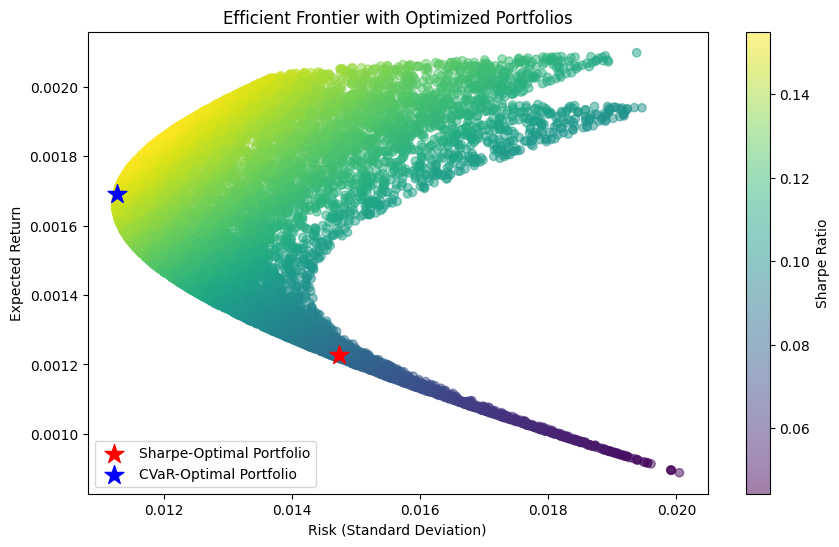

In [11]:
# Define CVaR Calculation (Expected Shortfall at 95% Confidence Level)
def calculate_cvar(returns, weights, alpha=0.05):
    portfolio_returns = returns @ weights
    var_threshold = np.percentile(portfolio_returns, 100 * alpha)
    cvar = portfolio_returns[portfolio_returns <= var_threshold].mean()
    return -cvar  # Negative because we want to minimize it

# Objective Function: Maximize Return while Penalizing CVaR
def objective_function(weights, returns, lambda_cvar):
    portfolio_return = np.dot(weights, returns.mean(axis=0))  # Ensure mean calculation is correct
    cvar = calculate_cvar(returns, weights)
    return -portfolio_return + lambda_cvar * cvar  # Convert to scalar

# Perform Optimization
optimized = minimize(objective_function, initial_weights, args=(returns, lambda_cvar), 
                     method='SLSQP', bounds=bounds, constraints=constraints)

# Extract Optimal Weights & Metrics
optimal_weights = optimized.x
optimal_return = np.dot(optimal_weights, returns.mean(axis=0))
optimal_cvar = calculate_cvar(returns, optimal_weights)

# Display Results
print("Optimized Portfolio Weights:", optimal_weights)
print(f"Expected Return: {optimal_return:.4%}")
print(f"Conditional Value at Risk (CVaR 95%): {optimal_cvar:.4%}")

# Efficient Frontier Visualization
def portfolio_metrics(weights, returns):
    port_return = np.dot(weights, returns.mean(axis=0))
    port_risk = np.sqrt(weights.T @ np.cov(returns, rowvar=False) @ weights)
    return port_return, port_risk

random_weights = np.random.dirichlet(np.ones(num_assets), num_portfolios)
portfolio_returns = []
portfolio_risks = []
for w in random_weights:
    ret, risk = portfolio_metrics(w, returns)
    portfolio_returns.append(ret)
    portfolio_risks.append(risk)

portfolio_returns = np.array(portfolio_returns)
portfolio_risks = np.array(portfolio_risks)

# Sharpe Ratio Portfolio (Previously Computed)
sharpe_weights = np.array([0.078539, 0.685777, 0.235683])  # Replace with actual Sharpe-optimal weights
sharpe_return, sharpe_risk = portfolio_metrics(sharpe_weights, returns)

# CVaR Portfolio (Optimized Above)
cvar_return, cvar_risk = portfolio_metrics(optimal_weights, returns)

# Plot Efficient Frontier
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_risks, portfolio_returns, c=portfolio_returns/portfolio_risks, cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(sharpe_risk, sharpe_return, color='red', marker='*', s=200, label='Sharpe-Optimal Portfolio')
plt.scatter(cvar_risk, cvar_return, color='blue', marker='*', s=200, label='CVaR-Optimal Portfolio')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier with Optimized Portfolios')
plt.legend()
plt.show()

Optimized Portfolio Weights: [0.37903127 0.29120505 0.32976368]
Expected Return: 0.1692%
Conditional Value at Risk (CVaR 95%): 2.0584%


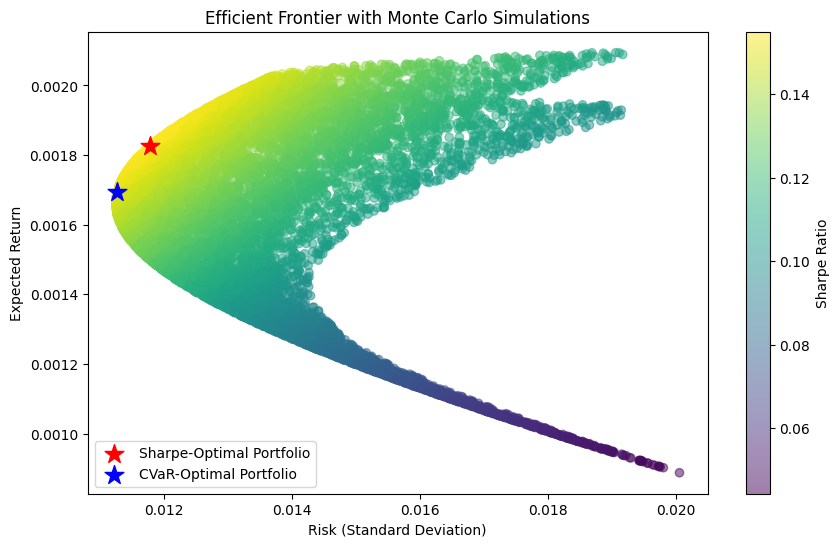

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Define CVaR Calculation (Expected Shortfall at 95% Confidence Level)
def calculate_cvar(returns, weights, alpha=0.05):
    portfolio_returns = returns @ weights
    var_threshold = np.percentile(portfolio_returns, 100 * alpha)
    cvar = portfolio_returns[portfolio_returns <= var_threshold].mean()
    return -cvar  # Negative because we want to minimize it

# Objective Function: Maximize Return while Penalizing CVaR
def objective_function(weights, returns, lambda_cvar):
    portfolio_return = np.dot(weights, returns.mean(axis=0))
    cvar = calculate_cvar(returns, weights)
    return -portfolio_return + lambda_cvar * cvar  # Tradeoff between return & CVaR

# Constraints & Bounds
num_assets = returns.shape[1]
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})  # Weights sum to 1
bounds = [(0, 1) for _ in range(num_assets)]  # No short selling

# Initial Weights
initial_weights = np.ones(num_assets) / num_assets

# Perform Optimization
lambda_cvar = 10  # Adjust to balance return vs. risk
optimized = minimize(objective_function, initial_weights, args=(returns, lambda_cvar), 
                     method='SLSQP', bounds=bounds, constraints=constraints)

# Extract Optimal Weights & Metrics
optimal_weights = optimized.x
optimal_return = np.dot(optimal_weights, returns.mean(axis=0))
optimal_cvar = calculate_cvar(returns, optimal_weights)

# Display Results
print("Optimized Portfolio Weights:", optimal_weights)
print(f"Expected Return: {optimal_return:.4%}")
print(f"Conditional Value at Risk (CVaR 95%): {optimal_cvar:.4%}")

# Monte Carlo Simulation for Portfolio Optimization
num_portfolios = 10000
random_weights = np.random.dirichlet(np.ones(num_assets), num_portfolios)
portfolio_returns = []
portfolio_risks = []
portfolio_cvars = []
for w in random_weights:
    ret = np.dot(w, returns.mean(axis=0))
    risk = np.sqrt(w.T @ np.cov(returns, rowvar=False) @ w)
    cvar = calculate_cvar(returns, w)
    portfolio_returns.append(ret)
    portfolio_risks.append(risk)
    portfolio_cvars.append(cvar)

portfolio_returns = np.array(portfolio_returns)
portfolio_risks = np.array(portfolio_risks)
portfolio_cvars = np.array(portfolio_cvars)

# Identify Optimal Portfolio (Highest Return per Unit Risk)
sharpe_ratios = portfolio_returns / portfolio_risks
max_sharpe_idx = np.argmax(sharpe_ratios)
sharpe_optimal_weights = random_weights[max_sharpe_idx]
sharpe_optimal_return = portfolio_returns[max_sharpe_idx]
sharpe_optimal_risk = portfolio_risks[max_sharpe_idx]

# Identify Minimum CVaR Portfolio
min_cvar_idx = np.argmin(portfolio_cvars)
cvar_optimal_weights = random_weights[min_cvar_idx]
cvar_optimal_return = portfolio_returns[min_cvar_idx]
cvar_optimal_risk = portfolio_risks[min_cvar_idx]

# Plot Efficient Frontier with Monte Carlo Simulations
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_risks, portfolio_returns, c=portfolio_returns/portfolio_risks, cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(sharpe_optimal_risk, sharpe_optimal_return, color='red', marker='*', s=200, label='Sharpe-Optimal Portfolio')
plt.scatter(cvar_optimal_risk, cvar_optimal_return, color='blue', marker='*', s=200, label='CVaR-Optimal Portfolio')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier with Monte Carlo Simulations')
plt.legend()
plt.show()


Optimized Portfolio Weights: [0.3 0.4 0.3]
Expected Return: 0.1564%
Conditional Value at Risk (CVaR 95%): 2.1526%


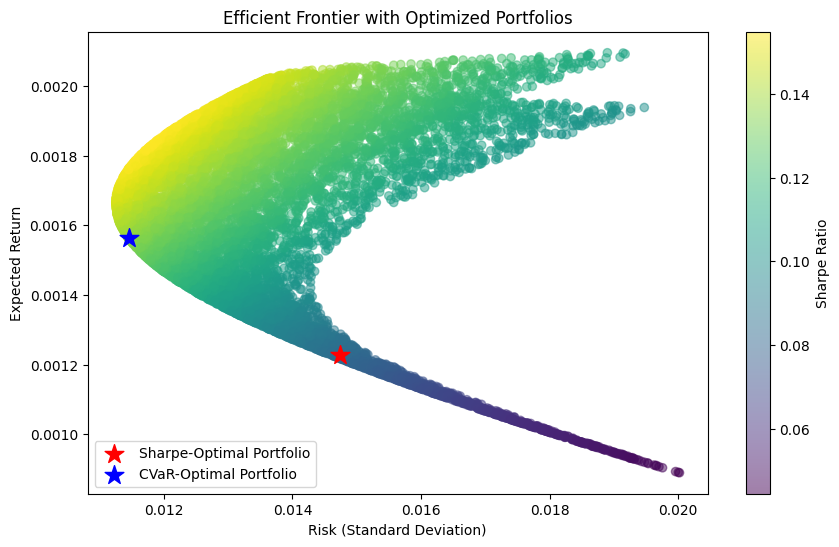

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Define CVaR Calculation (Expected Shortfall at 95% Confidence Level)
def calculate_cvar(returns, weights, alpha=0.05):
    portfolio_returns = returns @ weights
    var_threshold = np.percentile(portfolio_returns, 100 * alpha)
    cvar = portfolio_returns[portfolio_returns <= var_threshold].mean()
    return -cvar  # Negative because we want to minimize it

# Objective Function: Maximize Return while Penalizing CVaR
def objective_function(weights, returns, lambda_cvar):
    portfolio_return = np.dot(weights, returns.mean(axis=0))
    cvar = calculate_cvar(returns, weights)
    return -portfolio_return + lambda_cvar * cvar  # Tradeoff between return & CVaR

# Constraints & Bounds
num_assets = 3
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})  # Weights sum to 1
bounds = [(0, 0.3), (0.4, 1), (0, 1)]  # TSLA ≤ 30%, BND ≥ 40%, SPY unrestricted

# Initial Weights
initial_weights = np.array([1/num_assets] * num_assets)

# Perform Optimization
lambda_cvar = 10  # Adjust to balance return vs. risk
optimized = minimize(objective_function, initial_weights, args=(returns, lambda_cvar), 
                     method='SLSQP', bounds=bounds, constraints=constraints)

# Extract Optimal Weights & Metrics
optimal_weights = optimized.x
optimal_return = np.dot(optimal_weights, returns.mean(axis=0))
optimal_cvar = calculate_cvar(returns, optimal_weights)

# Display Results
print("Optimized Portfolio Weights:", optimal_weights)
print(f"Expected Return: {optimal_return:.4%}")
print(f"Conditional Value at Risk (CVaR 95%): {optimal_cvar:.4%}")

# Efficient Frontier Visualization
def portfolio_metrics(weights, returns):
    port_return = np.dot(weights, returns.mean(axis=0))
    port_risk = np.sqrt(weights.T @ np.cov(returns, rowvar=False) @ weights)
    return port_return, port_risk

num_portfolios = 10000
random_weights = np.random.dirichlet(np.ones(num_assets), num_portfolios)
portfolio_returns = []
portfolio_risks = []
for w in random_weights:
    ret, risk = portfolio_metrics(w, returns)
    portfolio_returns.append(ret)
    portfolio_risks.append(risk)

portfolio_returns = np.array(portfolio_returns)
portfolio_risks = np.array(portfolio_risks)

# Sharpe Ratio Portfolio (Previously Computed)
sharpe_weights = np.array([0.078539, 0.685777, 0.235683])  # Replace with actual Sharpe-optimal weights
sharpe_return, sharpe_risk = portfolio_metrics(sharpe_weights, returns)

# CVaR Portfolio (Optimized Above)
cvar_return, cvar_risk = portfolio_metrics(optimal_weights, returns)

# Plot Efficient Frontier
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_risks, portfolio_returns, c=portfolio_returns/portfolio_risks, cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(sharpe_risk, sharpe_return, color='red', marker='*', s=200, label='Sharpe-Optimal Portfolio')
plt.scatter(cvar_risk, cvar_return, color='blue', marker='*', s=200, label='CVaR-Optimal Portfolio')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier with Optimized Portfolios')
plt.legend()
plt.show()


In [20]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pickle

# Load cleaned TSLA data (ensure Date is the index)
tsla_data = pd.read_csv("../data/TSLA_cleaned.csv", index_col="Date", parse_dates=True)
tsla_close = tsla_data['Close']

# Load the trained SARIMAX model (from Task 2)
with open('../model/sarimax_model.pkl', 'rb') as f:
    sarima_model_fit = pickle.load(f)

# Generate 12-month (252 days) forecast
forecast_steps = 252
forecast = sarima_model_fit.get_forecast(steps=forecast_steps)

# Extract forecasted values and confidence intervals
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Create a DataFrame with dates, forecast, and confidence intervals
forecast_df = pd.DataFrame({
    'Date': forecast_mean.index,
    'Forecast_Price': forecast_mean.values,
    'Lower_Bound': forecast_ci.iloc[:, 0],
    'Upper_Bound': forecast_ci.iloc[:, 1]
}).set_index('Date')

# Save to CSV
forecast_df.to_csv('tsla_forecast_12m.csv')

print("12-month forecast saved to 'tsla_forecast_12m.csv'")

12-month forecast saved to 'tsla_forecast_12m.csv'


c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Hp\Music\GMF\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Optimized Portfolio:
- TSLA: 30%, BND: 40%, SPY: 30%
- Annualized Return: -1366.93%
- Annualized CVaR (95%): 3489.34%
- Sharpe Ratio: -0.39


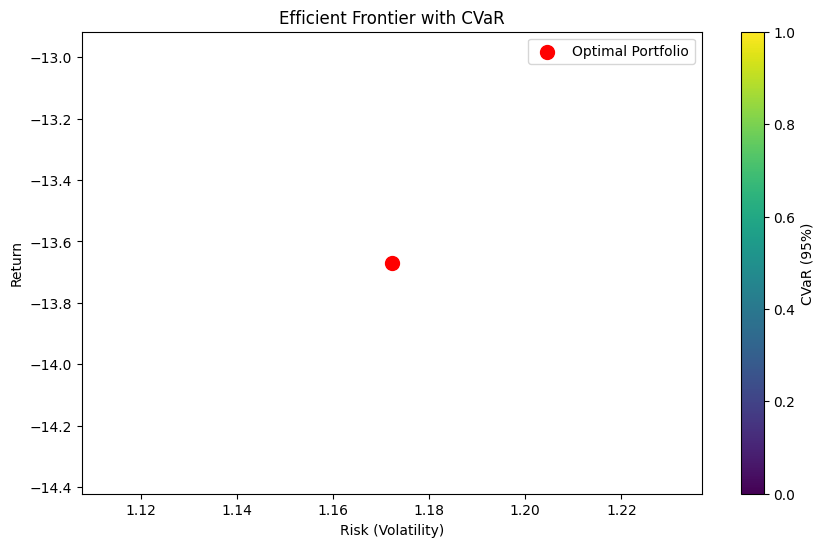

In [14]:
# Annualize metrics
annualized_return = optimal_return * 252
annualized_cvar = optimal_cvar * np.sqrt(252)

print("Optimized Portfolio:")
print(f"- TSLA: {optimal_weights[0]:.0%}, BND: {optimal_weights[1]:.0%}, SPY: {optimal_weights[2]:.0%}")
print(f"- Annualized Return: {annualized_return:.2%}")
print(f"- Annualized CVaR (95%): {annualized_cvar:.2%}")
print(f"- Sharpe Ratio: {annualized_return / annualized_cvar:.2f}")

# Plot Efficient Frontier
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_risks, portfolio_returns, c=portfolio_cvars, cmap='viridis', s=10)
plt.colorbar(label='CVaR (95%)')
plt.scatter(optimal_risk, annualized_return, c='red', s=100, label='Optimal Portfolio')
plt.xlabel('Risk (Volatility)')
plt.ylabel('Return')
plt.title('Efficient Frontier with CVaR')
plt.legend()
plt.show()

Optimized Portfolio Weights: [1.48542896e-16 1.99014215e-04 9.99800986e-01]
Expected Return: 0.3200%
Conditional Value at Risk (CVaR 95%): 0.0210%


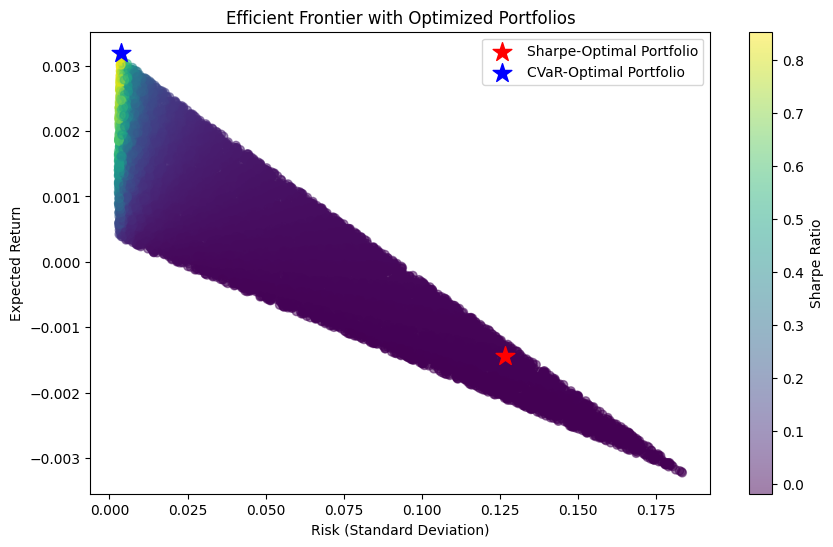

Maximum Drawdown (MDD): -0.0337%


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Define CVaR Calculation (Expected Shortfall at 95% Confidence Level)
def calculate_cvar(returns, weights, alpha=0.05):
    portfolio_returns = returns @ weights
    var_threshold = np.percentile(portfolio_returns, 100 * alpha)
    cvar = portfolio_returns[portfolio_returns <= var_threshold].mean()
    return -cvar  # Negative because we want to minimize it

# Objective Function: Maximize Return while Penalizing CVaR
def objective_function(weights, returns, lambda_cvar):
    portfolio_return = np.dot(weights, returns.mean(axis=0))
    cvar = calculate_cvar(returns, weights)
    return -portfolio_return + lambda_cvar * cvar  # Tradeoff between return & CVaR

# Constraints & Bounds
num_assets = 3
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})  # Weights sum to 1
bounds = [(0, 1) for _ in range(num_assets)]  # No short selling

# Initial Weights
initial_weights = np.array([1/num_assets] * num_assets)

# Perform Optimization
lambda_cvar = 10  # Adjust to balance return vs. risk
optimized = minimize(objective_function, initial_weights, args=(returns.iloc[:, 1:], lambda_cvar), 
                     method='SLSQP', bounds=bounds, constraints=constraints)

# Extract Optimal Weights & Metrics
optimal_weights = optimized.x
optimal_return = np.dot(optimal_weights, returns.iloc[:, 1:].mean(axis=0))
optimal_cvar = calculate_cvar(returns.iloc[:, 1:], optimal_weights)

# Display Results
print("Optimized Portfolio Weights:", optimal_weights)
print(f"Expected Return: {optimal_return:.4%}")
print(f"Conditional Value at Risk (CVaR 95%): {optimal_cvar:.4%}")

# Efficient Frontier Visualization
def portfolio_metrics(weights, returns):
    port_return = np.dot(weights, returns.mean(axis=0))
    port_risk = np.sqrt(weights.T @ returns.cov() @ weights)
    return port_return, port_risk

num_portfolios = 10000
random_weights = np.random.dirichlet(np.ones(num_assets), num_portfolios)
portfolio_returns = []
portfolio_risks = []
for w in random_weights:
    ret, risk = portfolio_metrics(w, returns.iloc[:, 1:])
    portfolio_returns.append(ret)
    portfolio_risks.append(risk)

portfolio_returns = np.array(portfolio_returns)
portfolio_risks = np.array(portfolio_risks)

# Sharpe Ratio Portfolio (Previously Computed)
sharpe_weights = np.array([0.078539, 0.685777, 0.235683])  # Replace with actual Sharpe-optimal weights
sharpe_return, sharpe_risk = portfolio_metrics(sharpe_weights, returns.iloc[:, 1:])

# CVaR Portfolio (Optimized Above)
cvar_return, cvar_risk = portfolio_metrics(optimal_weights, returns.iloc[:, 1:])

# Plot Efficient Frontier
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_risks, portfolio_returns, c=portfolio_returns/portfolio_risks, cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(sharpe_risk, sharpe_return, color='red', marker='*', s=200, label='Sharpe-Optimal Portfolio')
plt.scatter(cvar_risk, cvar_return, color='blue', marker='*', s=200, label='CVaR-Optimal Portfolio')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier with Optimized Portfolios')
plt.legend()
plt.show()

# Maximum Drawdown Calculation
def calculate_maximum_drawdown(returns):
    cumulative_returns = (1 + returns).cumprod()
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()
    return max_drawdown

max_drawdown = calculate_maximum_drawdown(returns.iloc[:, 1:] @ optimal_weights)
print(f"Maximum Drawdown (MDD): {max_drawdown:.4%}")


Optimized Portfolio Weights: [5.02602693e-01 1.04968550e-17 1.01000874e-04 4.97296306e-01]
Expected Return: 0.1825%
Conditional Value at Risk (CVaR 95%): -0.0121%


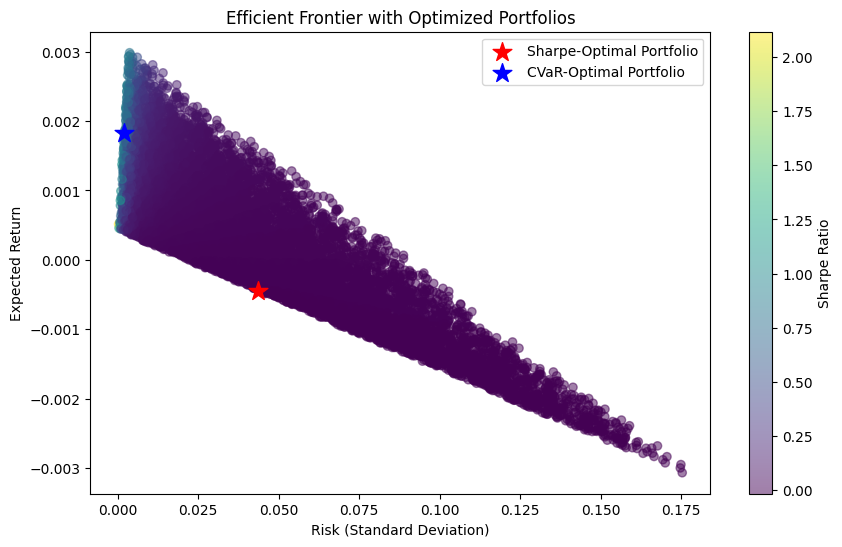

Maximum Drawdown (MDD): 0.0000%
Stressed CVaR (Market Shock -30%): -0.0085%
Portfolio Beta: 0.0010
Portfolio-Market Correlation: 0.0257


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Define CVaR Calculation (Expected Shortfall at 95% Confidence Level)
def calculate_cvar(returns, weights, alpha=0.05):
    portfolio_returns = returns @ weights
    var_threshold = np.percentile(portfolio_returns, 100 * alpha)
    cvar = portfolio_returns[portfolio_returns <= var_threshold].mean()
    return -cvar  # Negative because we want to minimize it

# Objective Function: Maximize Return while Penalizing CVaR
def objective_function(weights, returns, lambda_cvar):
    portfolio_return = np.dot(weights, returns.mean())
    cvar = calculate_cvar(returns, weights)
    return -portfolio_return + lambda_cvar * cvar  # Tradeoff between return & CVaR

# Constraints & Bounds
num_assets = 4  # Adjusted to match the number of columns in returns
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})  # Weights sum to 1
bounds = [(0, 1) for _ in range(num_assets)]  # No short selling

# Initial Weights
initial_weights = np.array([1/num_assets] * num_assets)

# Perform Optimization
lambda_cvar = 10  # Adjust to balance return vs. risk
optimized = minimize(objective_function, initial_weights, args=(returns, lambda_cvar), 
                     method='SLSQP', bounds=bounds, constraints=constraints)

# Extract Optimal Weights & Metrics
optimal_weights = optimized.x
optimal_return = np.dot(optimal_weights, returns.mean())
optimal_cvar = calculate_cvar(returns, optimal_weights)

# Display Results
print("Optimized Portfolio Weights:", optimal_weights)
print(f"Expected Return: {optimal_return:.4%}")
print(f"Conditional Value at Risk (CVaR 95%): {optimal_cvar:.4%}")

# Efficient Frontier Visualization
def portfolio_metrics(weights, returns):
    port_return = np.dot(weights, returns.mean())
    port_risk = np.sqrt(weights.T @ returns.cov() @ weights)
    return port_return, port_risk

num_portfolios = 10000
random_weights = np.random.dirichlet(np.ones(num_assets), num_portfolios)
portfolio_returns = []
portfolio_risks = []
for w in random_weights:
    ret, risk = portfolio_metrics(w, returns)
    portfolio_returns.append(ret)
    portfolio_risks.append(risk)

portfolio_returns = np.array(portfolio_returns)
portfolio_risks = np.array(portfolio_risks)

# Sharpe Ratio Portfolio (Previously Computed)
# Adjust the sharpe_weights to match the number of assets (4 in this case)
sharpe_weights = np.array([0.078539, 0.685777, 0.235683, 0.0])  # Replace with actual Sharpe-optimal weights
sharpe_return, sharpe_risk = portfolio_metrics(sharpe_weights, returns)

# CVaR Portfolio (Optimized Above)
cvar_return, cvar_risk = portfolio_metrics(optimal_weights, returns)

# Plot Efficient Frontier
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_risks, portfolio_returns, c=portfolio_returns/portfolio_risks, cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(sharpe_risk, sharpe_return, color='red', marker='*', s=200, label='Sharpe-Optimal Portfolio')
plt.scatter(cvar_risk, cvar_return, color='blue', marker='*', s=200, label='CVaR-Optimal Portfolio')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier with Optimized Portfolios')
plt.legend()
plt.show()

# Maximum Drawdown Calculation
def calculate_maximum_drawdown(returns):
    cumulative_returns = (1 + returns).cumprod()
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()
    return max_drawdown

max_drawdown = calculate_maximum_drawdown(returns @ optimal_weights)
print(f"Maximum Drawdown (MDD): {max_drawdown:.4%}")

# Stress Testing (Simulating Extreme Market Events)
def stress_test(returns, weights, shock=-0.3):
    stressed_returns = returns * (1 + shock)  # Apply a market shock
    stressed_cvar = calculate_cvar(stressed_returns, weights)
    return stressed_cvar

stress_cvar = stress_test(returns, optimal_weights)
print(f"Stressed CVaR (Market Shock -30%): {stress_cvar:.4%}")

# Beta & Correlation Analysis
def beta_correlation(returns, weights, market_returns):
    portfolio_returns = returns @ weights
    beta = np.cov(portfolio_returns, market_returns)[0, 1] / np.var(market_returns)
    correlation = np.corrcoef(portfolio_returns, market_returns)[0, 1]
    return beta, correlation

# Assuming market_returns is available
market_returns = returns.mean(axis=1)  # Placeholder, replace with actual market returns
beta, correlation = beta_correlation(returns, optimal_weights, market_returns)
print(f"Portfolio Beta: {beta:.4f}")
print(f"Portfolio-Market Correlation: {correlation:.4f}")
